In [1]:
!pip install matplotlib

### Starting Analysis  (actual insights, KPIs)

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 

In [11]:
pd.read_csv('dirty_cafe_clean.csv').shape

(10000, 19)

In [12]:
df['Transaction Date'] = pd.to_datetime(
    df['Transaction Date'],
    errors='coerce'
)


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Transaction ID          10000 non-null  str           
 1   Item                    9031 non-null   str           
 2   Quantity                9521 non-null   float64       
 3   Price Per Unit          9467 non-null   float64       
 4   Total Spent             9960 non-null   float64       
 5   Payment Method          6822 non-null   str           
 6   Location                6039 non-null   str           
 7   Transaction Date        9540 non-null   datetime64[us]
 8   location_raw            6735 non-null   str           
 9   location_missing        10000 non-null  int64         
 10  Item_raw                9667 non-null   str           
 11  Item_missing            10000 non-null  int64         
 12  Payment Method_raw      7421 non-null   str           
 13

### Why

We never analyze raw data

Clean data = trusted input

In [4]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Transaction ID          10000 non-null  str    
 1   Item                    9031 non-null   str    
 2   Quantity                9521 non-null   float64
 3   Price Per Unit          9467 non-null   float64
 4   Total Spent             9960 non-null   float64
 5   Payment Method          6822 non-null   str    
 6   Location                6039 non-null   str    
 7   Transaction Date        9540 non-null   str    
 8   location_raw            6735 non-null   str    
 9   location_missing        10000 non-null  int64  
 10  Item_raw                9667 non-null   str    
 11  Item_missing            10000 non-null  int64  
 12  Payment Method_raw      7421 non-null   str    
 13  Payment Method_missing  10000 non-null  int64  
 14  Quantity_raw            10000 non-null  str    
 1

### Why

Confirm we are working on the correct dataset

Check column names and types one last time

### 3 — Define EDA questions (THIS IS REAL EDA)

We do not start with charts.
We start with questions.

## EDA Questions

1. How much total revenue does the cafe generate?
2. Which items are sold the most?
3. Which items generate the most revenue?
4. How do customers prefer to pay?
5. Does missing data affect any analysis?


### 4 — KPI 1: Total Revenue
Question

How much total money did the cafe make?

Required columns

Total Spent

Decision

Drop rows where Total Spent is missing
(because money cannot be calculated without it)

In [14]:
revenue_df = df.dropna(subset=['Total Spent'])

total_revenue = revenue_df['Total Spent'].sum()
total_revenue


np.float64(88952.0)

### Why

This is analysis-time dropping

This is allowed and correct

### 5 — KPI 2: Total number of transactions
Question

How many valid transactions exist?

In [16]:
revenue_df.shape[0]


9960

### Why

Counts usable rows

Helps understand dataset size after filtering

### 6 — KPI 3: Most sold items (frequency)
Question

Which item is sold most often?

Required column

Item

Decision

Drop rows where Item is missing

In [17]:
item_df = df.dropna(subset=['Item'])

item_df['Item'].value_counts()


Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64

### Why

Missing item = cannot count sales

Dropping here does NOT affect other analyses

### 7 — KPI 4: Revenue by item
Question

Which item makes the most money?

Required columns

Item

Total Spent

In [18]:
item_revenue_df = df.dropna(subset=['Item', 'Total Spent'])

item_revenue_df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)


Item
Salad       17320.0
Sandwich    13664.0
Smoothie    13320.0
Juice       10509.0
Cake        10395.0
Coffee       7062.0
Tea          4951.5
Cookie       3223.0
Name: Total Spent, dtype: float64

### Why

This shows business insight



### 8 — KPI 5: Payment method preference
Question

How do customers usually pay?

Required column

Payment Method

In [20]:
payment_df = df.dropna(subset=['Payment Method'])

payment_df['Payment Method'].value_counts()


Payment Method
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64

### Why

Missing payment method = unknown

Known methods show real preference

### 9 — EDA insight check

### Initial Observations
- cafe makes revenue around 88952.0
- total 9960 transactions exists
- top most sold  Item were 
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089

- most revenue makine items : 
Salad       17320.0
Sandwich    13664.0
Smoothie    13320.0
Juice       10509.0
Cake        10395.0
Coffee       7062.0
Tea          4951.5
Cookie       3223.0
- customers paying behaviour
 Payment Method
Digital Wallet    2291
Credit Card       2273
Cash              2258
- Some items are sold much more frequently than others.
- Revenue is not evenly distributed across items.
- A significant number of transactions do not record payment method.
- Missing data reduces usable rows depending on the question.


### Chart 1: Total Revenue by Item
Question

Which items generate the most revenue?

Data needed

Item

Total Spent

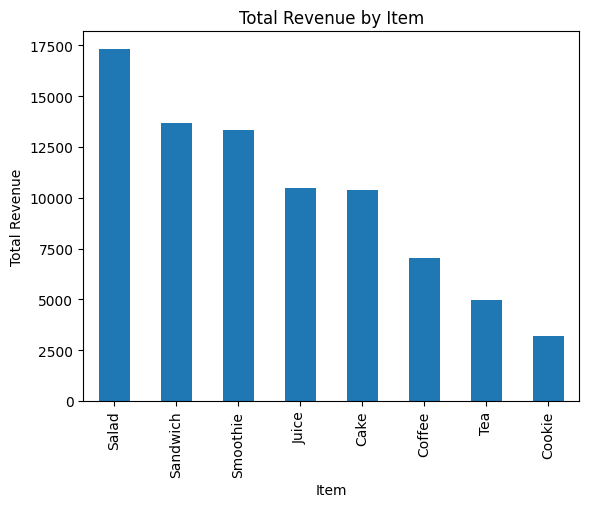

In [22]:
item_revenue = (
    df.dropna(subset=['Item', 'Total Spent'])
      .groupby('Item')['Total Spent']
      .sum()
      .sort_values(ascending=False)
)

plt.figure()
item_revenue.plot(kind='bar')
plt.title('Total Revenue by Item')
plt.xlabel('Item')
plt.ylabel('Total Revenue')
plt.show()


### Why this chart

Shows business importance, not just popularity

Helps identify high-value items

### Why this chart

Shows business importance, not just popularity

Helps identify high-value items

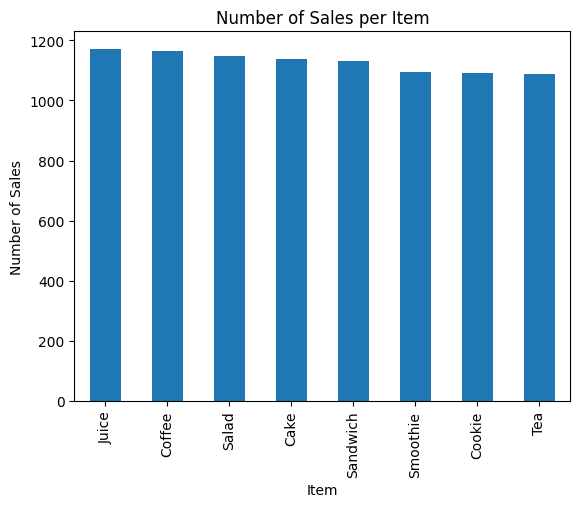

In [23]:
item_count = (
    df.dropna(subset=['Item'])
      ['Item']
      .value_counts()
)

plt.figure()
item_count.plot(kind='bar')
plt.title('Number of Sales per Item')
plt.xlabel('Item')
plt.ylabel('Number of Sales')
plt.show()


### Why this chart

Frequency ≠ revenue

Shows customer preference, not money

### Chart 3: Payment Method Distribution
Question

How do customers prefer to pay?

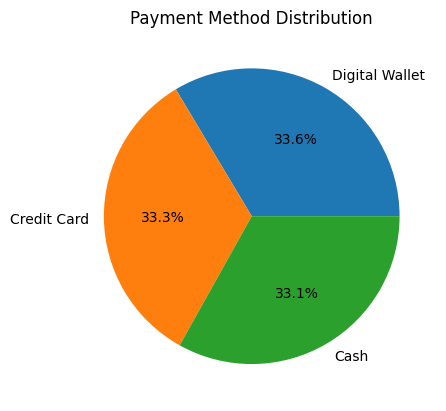

In [28]:
plt.figure()
payment_count.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.ylabel('')
plt.show()


### Why this chart

Helps understand customer behavior

Useful for operations and payment partnerships

### Chart 4: Missing Payment Method Impact
Question

How much data is missing for payment method?

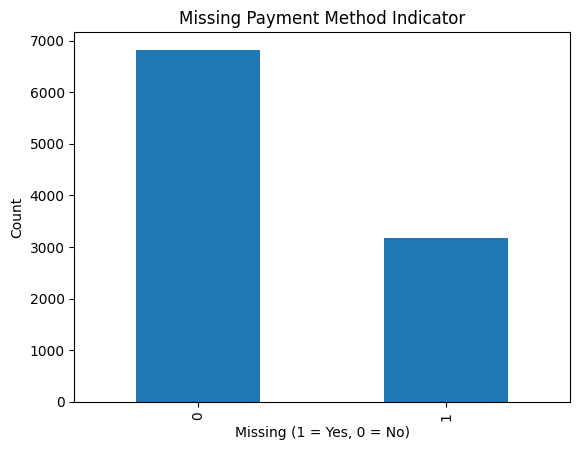

In [29]:
df['Payment Method_missing'].value_counts().plot(kind='bar')
plt.title('Missing Payment Method Indicator')
plt.xlabel('Missing (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()


### Why this chart

Shows data quality impact

Justifies why rows were dropped during analysis

## Initial Observations

- The cafe generated a total revenue of approximately **₹88,952** from the available data.
- There are **9,960 valid transactions** used for revenue analysis.

### Product Performance
- The most frequently sold items are:
  - Juice (1,171 orders)
  - Coffee (1,165 orders)
  - Salad (1,148 orders)
  - Cake (1,139 orders)
  - Sandwich (1,131 orders)
  - Smoothie (1,096 orders)
  - Cookie (1,092 orders)
  - Tea (1,089 orders)

- The items contributing the **highest revenue** are:
  - Salad – ₹17,320
  - Sandwich – ₹13,664
  - Smoothie – ₹13,320
  - Juice – ₹10,509
  - Cake – ₹10,395
  - Coffee – ₹7,062
  - Tea – ₹4,951.5
  - Cookie – ₹3,223

**Insight:**  
Some items are ordered frequently, but revenue contribution differs.  
For example, Salad and Sandwich generate more revenue even when sales volume is similar to other items.

---

### Customer Payment Behavior
- Among transactions where payment method is recorded:
  - Digital Wallet: 2,291 transactions
  - Credit Card: 2,273 transactions
  - Cash: 2,258 transactions

**Insight:**  
Customers use all payment methods almost equally. There is no strong preference for a single payment option.

---

### Data Quality Impact
- A significant number of transactions do not have payment method information recorded.
- This means payment behavior analysis is based only on available data and may not represent all customers.
- Missing data reduces the number of usable records depending on the question being analyzed.

---

### Overall Summary
- Revenue is not evenly distributed across items.
- High sales volume does not always mean high revenue.
- Data completeness affects how confident we can be in certain insights.
